In [38]:
import os
import image_tagger as it
from matplotlib import pyplot as plt

In [2]:
import pydantic

In [3]:
%load_ext autoreload
%autoreload 2

In [23]:
#project_dir = 'C:\\Users\\oloon\\OneDrive\\Desktop\\projects\\image_tagger'

input_dir = r"C:\Users\oloon\Dropbox\images\input"
output_dir = r"C:\Users\oloon\Dropbox\images\output"
metadata_filename = os.path.join(output_dir, 'image_metadata.csv')
gallery_filename = os.path.join(output_dir, 'index.html')

In [24]:
it.scramble_image_directory(input_dir, output_dir)

In [31]:
filepaths = it.find_images(output_dir)
print("number of image files:", len(filepaths))
filepaths

number of image files: 7


['C:\\Users\\oloon\\Dropbox\\images\\output\\CPDwekmU.png',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\HqPvwdNL.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\iLMcryuC.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\ljZCkwdh.webp',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\PnKNlpyj.jpg',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\qLeIXMSg.jpeg',
 'C:\\Users\\oloon\\Dropbox\\images\\output\\QwEZjicV.jpg']

In [32]:
it.tag_image(filepaths[0])

{'description': 'The image is a pixel art scene depicting a small, cartoonish character resembling a classic fantasy hero with blonde hair, wearing a green tunic and hat, holding a shield. The character is interacting with a round, blue creature with a large mouth and sharp teeth, which appears friendly as it has a heart symbol above it. They are standing on a stone path in front of a quaint, colorful house with a red-tiled roof. The environment is lush with green grass, small white flowers, and wooden posts. The top left corner shows a health bar with heart icons, and the top right corner displays a menu with icons, suggesting a video game interface.',
 'category': 'comic',
 'genre': 'fantasy',
 'tags': ['pixel art',
  'fantasy',
  'video game',
  'character',
  'creature',
  'house',
  'cartoon',
  'hero',
  'shield',
  'heart',
  'game interface'],
 'filename_already_makes_sense': False,
 'filename': 'pixel_art_hero_creature.png',
 'clean_filename': 'pixel_art_hero_creature.png',
 '

In [33]:
it.tag_images(filepaths, metadata_filename)

.......

In [34]:
import pandas as pd
metadata_df = pd.read_csv(metadata_filename)
print(metadata_df.shape)
print('n unique original filenames:', len(set(metadata_df['original_filename'])))
print('n unique clean filenames:', len(set(metadata_df['clean_filename'])))

# pd.set_option('display.max_rows', None)
# metadata_df[ metadata_df['clean_filename'].duplicated(keep=False) ].sort_values(['clean_filename'])[['original_filename', 'clean_filename']]

(7, 15)
n unique original filenames: 7
n unique clean filenames: 7


In [35]:
it.autorename(metadata_filename, verbose=1)

In [43]:
it.generate_gallery(metadata_filename, gallery_filename)

Text(0.5, 0, 'Number of Images')

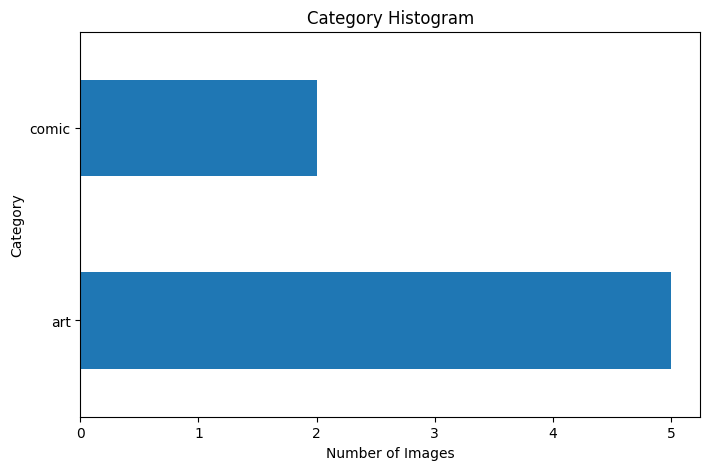

In [39]:
plt.figure(figsize=(8, 5))
metadata_df.groupby('category').size().plot.barh()
plt.title("Category Histogram")
plt.ylabel("Category")
plt.xlabel("Number of Images")

Text(0.5, 0, 'Number of Images')

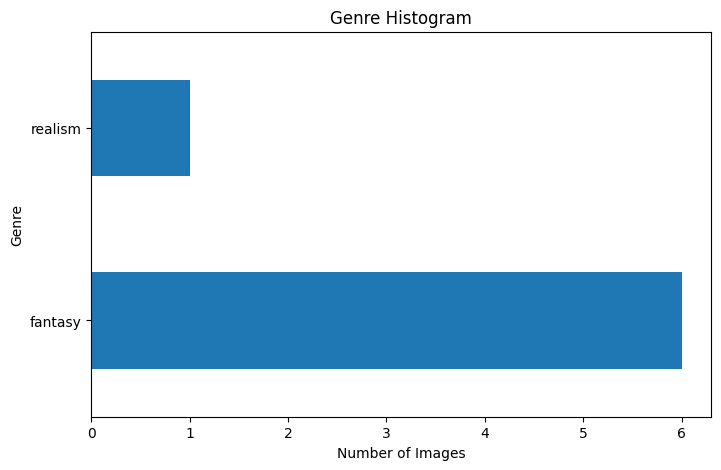

In [40]:
plt.figure(figsize=(8, 5))
metadata_df.groupby('genre').size().plot.barh()
plt.title("Genre Histogram")
plt.ylabel("Genre")
plt.xlabel("Number of Images")

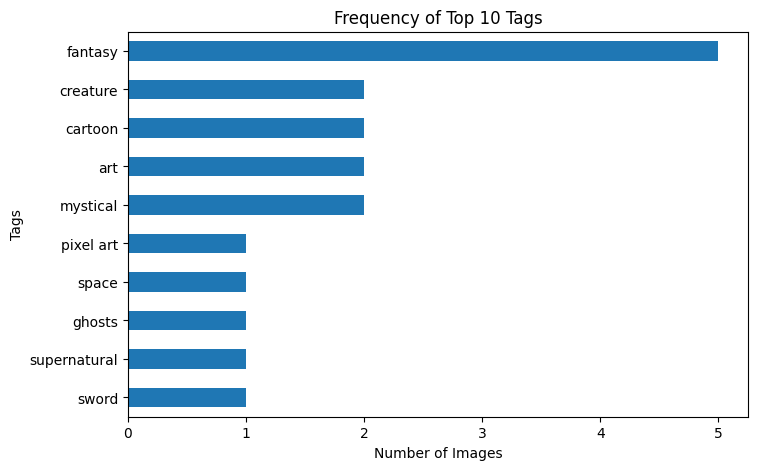

In [41]:
plt.figure(figsize=(8, 5))
tag_counts = metadata_df['tags'].str.split(';').explode('tags').value_counts()
top_tag_counts = tag_counts[:10][::-1]
top_tag_counts.plot.barh()

plt.xlabel('Number of Images')
plt.ylabel('Tags')
plt.title('Frequency of Top 10 Tags')
plt.show()

quartiles [-9.22337204e+09  3.49616400e+00  3.76055900e+00  4.32394900e+00
  5.31797300e+00]


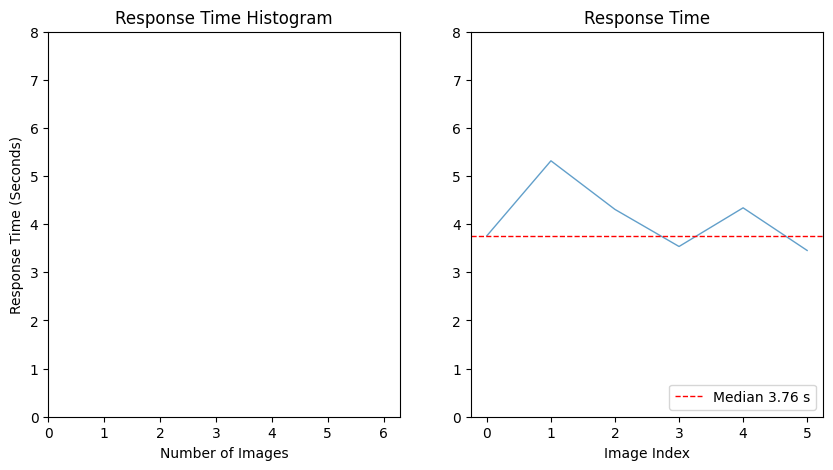

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
delta_seconds = np.array(pd.to_datetime(metadata_df['timestamp']).diff().astype(np.int64)/1e9)

print('quartiles', np.quantile(delta_seconds, [0, 0.25, 0.5, 0.75, 1]))
bounds = np.quantile(delta_seconds, [0.05, 0.95]) # 90% CI
bounded = np.clip(delta_seconds, bounds[0], bounds[1])

plt.subplot(121)
plt.hist(bounded, bins=16, orientation='horizontal', rwidth=0.8)
plt.ylim(0, 8)
plt.ylabel("Response Time (Seconds)")
plt.xlabel("Number of Images")
plt.title("Response Time Histogram")

plt.subplot(122)
plt.plot(delta_seconds[1:], lw=1, alpha=0.7)
plt.ylim(0, 8)
median = np.median(delta_seconds)
plt.axhline(median, linestyle='dashed', label=f'Median {median:0.2f} s', color='red', lw=1)
plt.legend(loc='lower right')
plt.xlabel("Image Index")
plt.title("Response Time");